In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/workspaces/Dynamic-Pricing/dynamic_pricing.csv')
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   str    
 3   Customer_Loyalty_Status  1000 non-null   str    
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   str    
 7   Vehicle_Type             1000 non-null   str    
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 78.3 KB


In [ ]:
def clean_data(df):
    df = df.dropna()
    df['Average_Ratings'] = pd.to_numeric(df['Average_Ratings'], errors='coerce')
    df = df.dropna(subset=['Average_Ratings'])
    return df

In [8]:
df['Historical_Cost_of_Ride'].describe()
#df['Location_Category'].unique()
#df['Average_Ratings'].describe()

count    1000.000000
mean      372.502623
std       187.158756
min        25.993449
25%       221.365202
50%       362.019426
75%       510.497504
max       836.116419
Name: Historical_Cost_of_Ride, dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

Location Distribution

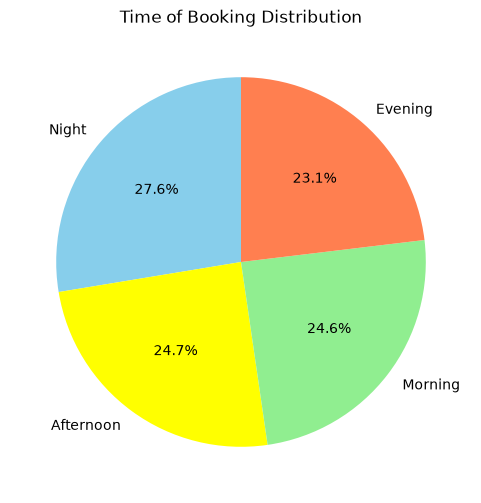

In [13]:
time_of_booking_counts = df['Time_of_Booking'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(time_of_booking_counts, labels=time_of_booking_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'yellow', 'lightgreen', 'coral' ]) 
plt.title('Time of Booking Distribution')
plt.show()

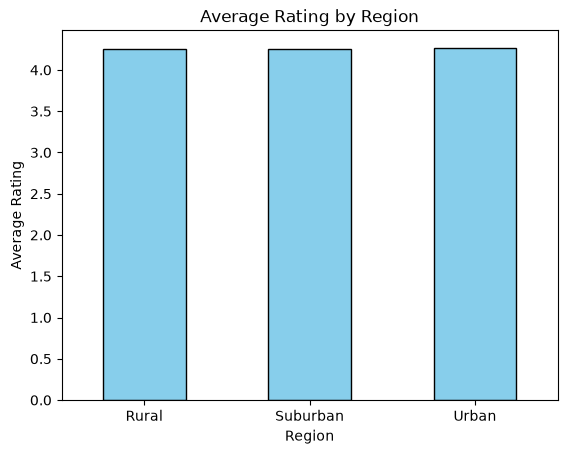

In [4]:
avg_rating = df.groupby('Location_Category')['Average_Ratings'].mean()
avg_rating.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Rating by Region')
plt.xlabel('Region')
plt.ylabel('Average Rating')
plt.xticks(rotation=0) 
plt.show()

Historical Cost of Ride depending on the region

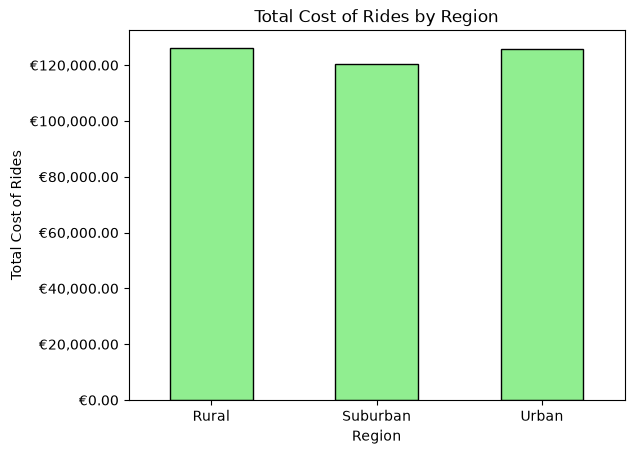

In [26]:
import matplotlib.ticker as ticker
cost_of_ride = df.groupby('Location_Category')['Historical_Cost_of_Ride'].sum()
cx = cost_of_ride.plot(kind='bar', color='lightgreen', edgecolor='black')
formatter = ticker.StrMethodFormatter('€{x:,.2f}')
cx.yaxis.set_major_formatter(formatter)
plt.title('Total Cost of Rides by Region')
plt.xlabel('Region')
plt.ylabel('Total Cost of Rides')
plt.xticks(rotation=0)
plt.show()

Average Revenue

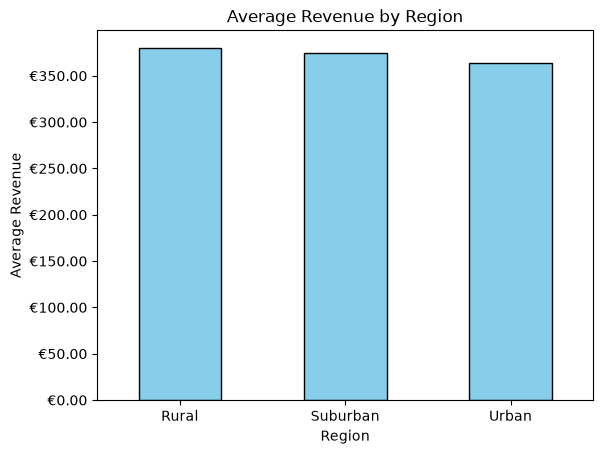

In [27]:
import matplotlib.ticker as ticker
avg_revenue = df.groupby('Location_Category')['Historical_Cost_of_Ride'].mean()
ax = avg_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
formatter = ticker.StrMethodFormatter('€{x:,.2f}')
ax.yaxis.set_major_formatter(formatter)
plt.title('Average Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Average Revenue')
plt.xticks(rotation=0) 
plt.show()